In [1]:
import torch 
import torchinfo

import numpy as np
import pandas as pd
import polars as pl

from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

import random



## Dataset

In [2]:
def pad_lightcurves(lcs_parquet, columns_to_pad = ["TIME", "FLUX", "FLUXERR", "BAND"]):

    maxlen = max(lcs_parquet["TIME"].list.len())

    for col in columns_to_pad:
        
        lcs_parquet = lcs_parquet.with_columns((pl.col(col)).alias(col + "_PAD"))
        
        lcs_parquet = lcs_parquet.with_columns(pl.col(col + "_PAD").list.concat(pl.lit(0).repeat_by(maxlen - pl.col(col).list.len())))
         
    lcs_parquet = lcs_parquet.with_columns(pl.lit(False).repeat_by(pl.col(col).list.len()).list.concat(pl.lit(True).repeat_by(maxlen - pl.col(col).list.len())).alias("MASK_PAD"))

    return lcs_parquet

def reformat_bands(lcs_parquet):
    
    band_dic = {"u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "Y": 5, "y": 5, "0": -1}

    lcs_parquet = lcs_parquet.with_columns(pl.col("BAND_PAD").map_elements(lambda bands: pl.Series([band_dic.get(b, -1) for b in bands], 
                                                                                                   dtype = pl.Int32), 
                                                                                                   return_dtype = pl.List(pl.Int32),
                                                                          ).alias("BAND_NUMBER"))
    return lcs_parquet

In [3]:
class Augmented_Dataset(torch.utils.data.dataset.Dataset):

    def __init__(self, file_path): 

        self.lcs_parquet = pl.read_parquet(file_path)
        self.lcs_parquet = pad_lightcurves(self.lcs_parquet)
        self.lcs_parquet = reformat_bands(self.lcs_parquet)

    def __len__(self):

        return len(self.lcs_parquet)

    def __getitem__(self, idx):

        time = torch.tensor(self.lcs_parquet["TIME_PAD"][idx].to_numpy().flatten())
        mask_pad = torch.tensor(self.lcs_parquet["MASK_PAD"][idx].to_numpy().flatten())
        time[~mask_pad] = time[~mask_pad] - torch.min(time[~mask_pad])

        flux = torch.tensor(self.lcs_parquet["FLUX_PAD"][idx].to_numpy().flatten())
        flux_err = torch.tensor(self.lcs_parquet["FLUXERR_PAD"][idx].to_numpy().flatten())
        band = torch.tensor(self.lcs_parquet["BAND_NUMBER"][idx].to_numpy())

        redshift = torch.tensor(self.lcs_parquet["Z"][idx])
        ebv = torch.tensor(self.lcs_parquet["EBV"][idx])

        data = torch.stack([time, band, flux, flux_err]).to(torch.float32)
        meta = torch.stack([redshift, ebv])
        target = torch.tensor(self.lcs_parquet["target"][idx])

        return data, meta, target


## Model

In [4]:
class GRU_Model(torch.nn.Module): 

    def __init__(self, input_size, hidden_size, mlp_hidden_size, num_layers = 1, dropout = 0.2, device = "mps"): 

        super().__init__()

        self.gru_layer_1 = torch.nn.GRU(input_size, hidden_size, num_layers, batch_first = True, bidirectional = True)     # * 2 because bidirectional = True
        self.gru_layer_2 = torch.nn.GRU(hidden_size * 2, hidden_size, num_layers, batch_first = True, bidirectional = True)
        self.hidden_bn = torch.nn.BatchNorm1d(hidden_size * 2)
        self.dropout = torch.nn.Dropout(dropout)
        self.mlp = torch.nn.Sequential(
                                       torch.nn.Linear(hidden_size * 2, mlp_hidden_size),
                                       torch.nn.ReLU(),
                                       torch.nn.Dropout(dropout),
                                       torch.nn.Linear(mlp_hidden_size, 1),
                                       torch.nn.Sigmoid(),  
                                      )

        self.to(device)

    def forward(self, input):

        input = input.transpose(1, 2)
        
        out1, _ = self.gru_layer_1(input)    
        out1 = self.dropout(out1)                    
        out1 = self.hidden_bn(out1.transpose(1, 2)).transpose(1, 2)   

        out2, _ = self.gru_layer_2(out1) 
        out2 = self.dropout(out2)                  
        out2 = self.hidden_bn(out2.transpose(1, 2)).transpose(1, 2)

        last_hidden = out2[:, -1, :]                           
        output = self.mlp(last_hidden)

        return output

In [5]:
class CNN_Shallow_Model(torch.nn.Module):
    def __init__(self, dropout=0.3, device="mps"):
        super().__init__()
        self.cnn = torch.nn.Sequential(
            torch.nn.Conv1d(4, 16, kernel_size=7, padding=3),
            torch.nn.BatchNorm1d(16),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(2),

            torch.nn.Conv1d(16, 32, kernel_size=5, padding=2),
            torch.nn.BatchNorm1d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(2),

            torch.nn.Conv1d(32, 62, kernel_size=3, padding=1),
            torch.nn.BatchNorm1d(62),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1)               
        )
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(32, 3),
        )
        self.to(device)

    def forward(self, x, meta):

        x = self.cnn(x)             
        x = x.flatten(start_dim = 1)  
        x = torch.cat([x, meta], dim = 1)
        return self.mlp(x)
    
cnn = CNN_Shallow_Model()
# torchinfo.summary(cnn.cnn, input_size = [64, 4, 990])

In [6]:
class CNN_Model(torch.nn.Module):
    def __init__(self, dropout_cnn = 0.1, dropout_mlp = 0.3, device = "mps"):
        super().__init__()
        self.cnn = torch.nn.Sequential(
            torch.nn.Conv1d(4, 32, kernel_size=7, padding=3),
            torch.nn.BatchNorm1d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(2),
            torch.nn.Dropout1d(dropout_cnn),        

            torch.nn.Conv1d(32, 32, kernel_size=5, padding=2),
            torch.nn.BatchNorm1d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(2),
            torch.nn.Dropout1d(dropout_cnn),        

            torch.nn.Conv1d(32, 62, kernel_size=5, padding=2),
            torch.nn.BatchNorm1d(62),
            torch.nn.ReLU(),
            torch.nn.Dropout1d(dropout_cnn),

            torch.nn.Conv1d(62, 62, kernel_size=3, padding=1),
            torch.nn.BatchNorm1d(62),
            torch.nn.ReLU(),
            torch.nn.Dropout1d(dropout_cnn),

            torch.nn.AdaptiveAvgPool1d(1)
        )
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout1d(dropout_mlp),
            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),
            torch.nn.Dropout1d(dropout_mlp),
            torch.nn.Linear(16, 3),
        )
        self.to(device)

    def forward(self, x, meta):

        x = self.cnn(x)             
        x = x.flatten(start_dim = 1)  
        x = torch.cat([x, meta], dim = 1)
        return self.mlp(x)
    
cnn = CNN_Model()
# torchinfo.summary(cnn.cnn, input_size = [64, 4, 990])

## Trainer

In [7]:
def collate_fn(batch):
    data, masks, targets = zip(*batch)
    
    # Find longest real sequence in this batch (not global max)
    real_lengths = [(~m).sum().item() for m in masks]
    max_len = max(real_lengths)
    # print("Fraction padded:", np.mean(real_lengths) / )
    # print("Max padded length:", max_len)
    
    # Truncate everything to max_len
    data    = torch.stack([d[:, :max_len] for d in data])
    masks   = torch.stack([m[:max_len]    for m in masks])
    targets = torch.stack(list(targets))
    return data, masks, targets

class Binary_Class_Trainer: 

    def __init__(self, model: torch.nn.Module, seed: int = 1337, device: str = "mps"):

        self.device = device
        self.model = model.to(self.device)

        self.seed = seed
        self.thresholds = np.linspace(0, 1, 100)
    
    def set_seeds(self):

        torch.manual_seed(self.seed)
        np.random.seed(self.seed)
    
    def get_dataloaders(self, train_dataset: torch.utils.data.Dataset, validation_dataset: torch.utils.data.Dataset) -> tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader]:
    
        train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True, collate_fn = collate_fn,
                                                       generator = torch.Generator().manual_seed(self.seed))
        
        validation_dataloader = torch.utils.data.DataLoader(validation_dataset, batch_size = 32, shuffle = False, collate_fn = collate_fn,
                                                            generator = torch.Generator().manual_seed(self.seed))
        
        return train_dataloader, validation_dataloader
    
    def get_predictions(self, dataset: torch.utils.data.Dataset) -> tuple[torch.Tensor, torch.Tensor]:
        
        predictions, targets = [], []
        loader = torch.utils.data.DataLoader(dataset, batch_size = 8)

        with torch.no_grad():
            for lc_data, _, target in loader:

                pred = self.model(lc_data.to(self.device)).cpu().squeeze(1)
                predictions.append(pred)
                targets.append(target)

        return torch.cat(predictions), torch.cat(targets)

    def accuracy_for_thresholds(self, predictions, targets):
        
        accs = []
        for t in self.thresholds:
            pred_labels = (predictions > t).int()
            accuracy = (pred_labels == targets).float().mean().item()
            accs.append(accuracy)

        return accs

    def train(self, train_dataset: torch.utils.data.Dataset, validation_dataset: torch.utils.data.Dataset, 
              optimiser: torch.optim, learning_rate: float, max_epochs: int, epochs_early_stopping: int, 
              threshold_early_stopping: float, print_log: bool = True):
        
        self.set_seeds()

        train_dataloader, validation_dataloader = self.get_dataloaders(train_dataset, validation_dataset)
        optim = optimiser(self.model.parameters(), lr = learning_rate, weight_decay = 1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode = "min", factor = 0.5, patience = 3)

        all_targets = torch.cat([tgt for _, _, tgt in train_dataloader])
        neg_count = (all_targets == 0).sum().item()
        pos_count = (all_targets == 1).sum().item()
        pos_weight = torch.tensor([neg_count / pos_count]).to(self.device)

        print(f"Negative samples: {neg_count}")
        print(f"Positive samples: {pos_count}")
        print(f"Ratio (pos_weight): {neg_count / pos_count:.2f}")

        total_train_loss, total_val_loss = [], []

        previous_val_loss = 0
        nr_no_improvement = 1

        for epoch in range(max_epochs):

            # training
            self.model.train()
            train_loss, val_loss = [], []

            for lc_data, mask, tgt in train_dataloader:

                optim.zero_grad()
                pred = self.model(lc_data.to(self.device))
                loss = torch.nn.functional.binary_cross_entropy_with_logits(pred, tgt.float().unsqueeze(-1).to(self.device), pos_weight = pos_weight)
                train_loss.append(loss.item())
                loss.backward()
                optim.step()

            # Check what fraction is padding
            print("Fraction padded:", mask.float().mean().item())  # e.g. 0.90 means 90% is padding

            # # Check flux stats on real values only
            # real_flux = lc_data[:, 2, :][~mask]
            # print("Real flux mean:", real_flux.mean().item())   # should be ~0.5
            # print("Real flux std:",  real_flux.std().item())    # should be ~0.3

            mean_train_loss = np.mean(train_loss)
            total_train_loss.append(mean_train_loss)

            # validation
            self.model.eval()
            val_preds, val_tgts = [], []

            with torch.no_grad():
                for lc_data, mask, tgt in validation_dataloader:
                    
                    pred = self.model(lc_data.to(self.device))
                    loss = torch.nn.functional.binary_cross_entropy_with_logits(pred, tgt.float().unsqueeze(-1).to(self.device), pos_weight = pos_weight)
                    val_loss.append(loss.item())

                    val_preds.append(pred.cpu())
                    val_tgts.append(tgt.cpu())

            mean_val_loss = np.mean(val_loss)
            total_val_loss.append(mean_val_loss)

            # accuracy 
            preds = torch.cat(val_preds).squeeze(1)
            targets = torch.cat(val_tgts)

            val_accuracy = ((preds > 0.5).int() == targets).float().mean().item()

            accuracy_curve = self.accuracy_for_thresholds(preds, targets)
            max_val_accuracy = np.max(accuracy_curve)
            best_threshold = self.thresholds[np.argmax(accuracy_curve)]

            if print_log:
                print(f"Epoch {epoch}: train_loss={mean_train_loss:.4f}, val_loss={mean_val_loss:.4f}, val_acc={val_accuracy:.4f}, max_val_acc={max_val_accuracy:.4f}, best threshold={best_threshold:.4f}")

            if np.abs(previous_val_loss - mean_val_loss) < threshold_early_stopping:
                nr_no_improvement += 1
            else:
                previous_val_loss = mean_val_loss
                nr_no_improvement = 1

            if nr_no_improvement >= epochs_early_stopping:
                break

            scheduler.step(mean_val_loss)

        return total_train_loss, total_val_loss

    def save_model(self, path: str):

        torch.save(self.model.state_dict(), path)

In [8]:
class Multi_Class_Model_Trainer: 

    def __init__(self, model: torch.nn.Module, seed: int = 1337, device: str = "mps"):

        self.device = device
        self.model = model.to(self.device)

        self.seed = seed
    
    def set_seeds(self):

        torch.manual_seed(self.seed)
        np.random.seed(self.seed)
    
    def get_dataloaders(self, train_dataset: torch.utils.data.Dataset, validation_dataset: torch.utils.data.Dataset) -> tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader]:
    
        train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size = 128, shuffle = True, # collate_fn = collate_fn,
                                                       generator = torch.Generator().manual_seed(self.seed))
        
        validation_dataloader = torch.utils.data.DataLoader(validation_dataset, batch_size = 64, shuffle = False, # collate_fn = collate_fn,
                                                            generator = torch.Generator().manual_seed(self.seed))
        
        return train_dataloader, validation_dataloader

    def train(self, train_dataset: torch.utils.data.Dataset, validation_dataset: torch.utils.data.Dataset, 
              optimiser: torch.optim, learning_rate: float, lr_shedule: str, max_epochs: int, patience_early_stopping: int, 
              threshold_early_stopping: float, incl_weight: bool = False, print_log: bool = True):
        
        self.set_seeds()

        train_dataloader, validation_dataloader = self.get_dataloaders(train_dataset, validation_dataset)
        
        optim = optimiser(filter(lambda p: p.requires_grad, self.model.parameters()), lr = learning_rate, weight_decay = 1e-4)
        if lr_shedule == "cosine_annealing":
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max = max_epochs)
            # scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, gamma = 0.90)
        elif lr_shedule == "reduce_on_plateau":
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode = "min", factor = 0.1, patience = 5)

        if incl_weight: 
            all_targets = torch.cat([tgt for _, _, tgt in train_dataloader])
            weight = torch.Tensor([len(all_targets) / (2 * (all_targets == tgt_nr).sum().item()) for tgt_nr in range(3)]).to(self.device)

        else: 
            weight = torch.Tensor([1, 1, 1]).to(self.device)
        
        print("Weights: ", weight)

        total_train_loss, total_val_loss = [], []

        best_val_loss = np.inf
        patience_counter = 0

        for epoch in range(max_epochs):

            # training
            self.model.train()
            train_loss, val_loss = [], []

            for lc_data, meta, tgt in train_dataloader:

                optim.zero_grad()
                pred = self.model(lc_data.to(self.device), meta.to(self.device))
                loss = torch.nn.functional.cross_entropy(pred.float(), tgt.float().to(self.device), weight = weight) #, pos_weight = pos_weight)
                train_loss.append(loss.item())
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm = 1)
                optim.step()

            mean_train_loss = np.mean(train_loss)
            total_train_loss.append(mean_train_loss)

            # validation
            self.model.eval()
            val_preds, val_tgts = [], []

            with torch.no_grad():
                for lc_data, meta, tgt in validation_dataloader:
                    
                    pred = self.model(lc_data.to(self.device), meta.to(self.device))
                    loss = torch.nn.functional.cross_entropy(pred.float(), tgt.float().to(self.device), weight = weight) #, pos_weight = pos_weight)
                    val_loss.append(loss.item())

                    val_preds.append(torch.argmax(torch.softmax(pred, dim = 1), dim = 1).cpu())
                    val_tgts.append(tgt.cpu())

            mean_val_loss = np.mean(val_loss)
            total_val_loss.append(mean_val_loss)

            # accuracy 
            preds = torch.cat(val_preds)
            targets = torch.cat(val_tgts)

            val_accuracy = (preds == targets).float().mean().item()
            val_f1_score = f1_score(targets.float().numpy(), preds.float().numpy(), average = None)

            if print_log:
                print(f"Epoch {epoch}: train_loss={mean_train_loss:.4f}, val_loss={mean_val_loss:.4f}, val_acc={val_accuracy:.4f}, val_f1_score={val_f1_score}")

            # early stopping
            if mean_val_loss < best_val_loss - threshold_early_stopping:   
                best_val_loss = mean_val_loss
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience_early_stopping:
                print(f"Early stopping at epoch {epoch}")
                break

            if lr_shedule == "cosine_annealing":
                scheduler.step()
            elif lr_shedule == "reduce_on_plateau": 
                scheduler.step(mean_val_loss)
            
        return total_train_loss, total_val_loss

    def save_model(self, path: str):

        torch.save(self.model.state_dict(), path)

## Evaluation

In [9]:
def set_seeds(seed: int = 1337):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed) 

### Test code for multi-class classification

##### Pretrain

In [ ]:

set_seeds()

augmented_lcs_path = "../../mallorn_data/augmented_lcs/combined_multi_class_augmented_lcs.parq"
augmented_lcs = Augmented_Dataset(augmented_lcs_path)

train_augmented_dataset, validation_augmented_dataset = torch.utils.data.random_split(augmented_lcs, [4200, 1800])

pretrain_model = CNN_Model()

pretrain_trainer = Multi_Class_Model_Trainer(pretrain_model)

train_pretrain_loss, val_pretrain_loss = pretrain_trainer.train(train_augmented_dataset, validation_augmented_dataset, optimiser = torch.optim.Adam, learning_rate = 1e-3, lr_shedule = "cosine_annealing",
                                                                max_epochs = 750, patience_early_stopping = 50, threshold_early_stopping = 0.001, incl_weight = False, print_log = True)


Weights:  tensor([1., 1., 1.], device='mps:0')
Epoch 0: train_loss=1.0950, val_loss=1.0862, val_acc=0.3767, val_f1_score=[0.26149425 0.         0.51176983]
Epoch 1: train_loss=1.0817, val_loss=1.0693, val_acc=0.4072, val_f1_score=[0.39540816 0.02889246 0.51892385]
Epoch 2: train_loss=1.0621, val_loss=1.0356, val_acc=0.4856, val_f1_score=[0.64790997 0.27664975 0.46173469]
Epoch 3: train_loss=1.0399, val_loss=1.0148, val_acc=0.4522, val_f1_score=[0.6013986  0.29638854 0.33117484]
Epoch 4: train_loss=1.0284, val_loss=0.9793, val_acc=0.5461, val_f1_score=[0.6585736  0.61371841 0.27647715]
Epoch 5: train_loss=1.0171, val_loss=0.9694, val_acc=0.5594, val_f1_score=[0.61950287 0.66315789 0.27488152]
Epoch 6: train_loss=1.0150, val_loss=0.9596, val_acc=0.5367, val_f1_score=[0.65429234 0.58555133 0.31854839]
Epoch 7: train_loss=1.0197, val_loss=0.9516, val_acc=0.5506, val_f1_score=[0.6528777  0.61634349 0.35057471]
Epoch 8: train_loss=1.0005, val_loss=0.9438, val_acc=0.5700, val_f1_score=[0.6420

In [16]:
torch.save(pretrain_trainer.model.state_dict(), "../models/pretrain/pretrained_torch_grad_clipping_v02.pt")


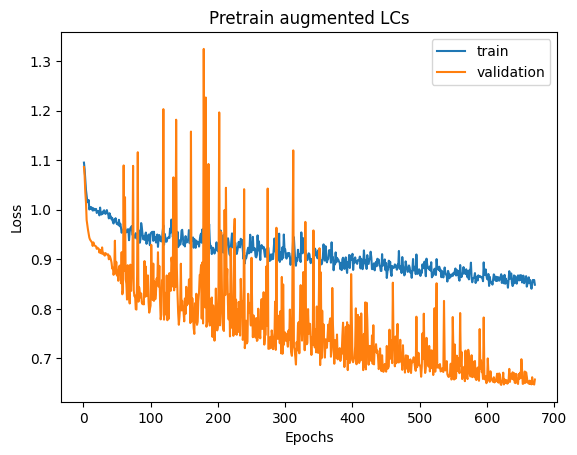

In [14]:
plt.plot(np.arange(len(train_pretrain_loss), dtype = int) + 1, train_pretrain_loss, label = "train")
plt.plot(np.arange(len(val_pretrain_loss), dtype = int) + 1, val_pretrain_loss, label = "validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Pretrain augmented LCs")
plt.legend()
plt.show()

##### MLP finetune

In [ ]:

set_seeds()

original_lcs_path = "../../mallorn_data/combined_multi_class_original_lcs.parq"
original_lcs = Augmented_Dataset(original_lcs_path)

train_original_dataset, validation_original_dataset = torch.utils.data.random_split(original_lcs, [2131, 912])

finetune_model = CNN_Model()
finetune_model.load_state_dict(torch.load("../models/pretrain/pretrained_torch_grad_clipping_v02.pt"))
finetune_model.cnn.requires_grad_(False)

finetune_trainer = Multi_Class_Model_Trainer(finetune_model)

train_finetune_loss, val_finetune_loss = finetune_trainer.train(train_original_dataset, validation_original_dataset, optimiser = torch.optim.Adam, learning_rate = 1e-5, lr_shedule = "",
                                                                max_epochs = 500, patience_early_stopping = 20, threshold_early_stopping = 0.0001, incl_weight = True, print_log = True)

Weights:  tensor([ 0.8551,  1.3625, 10.3447], device='mps:0')
Epoch 0: train_loss=0.9075, val_loss=0.7208, val_acc=0.7610, val_f1_score=[0.80748075 0.90855457 0.16033755]
Epoch 1: train_loss=0.8730, val_loss=0.7218, val_acc=0.7621, val_f1_score=[0.81009879 0.90694239 0.16101695]
Epoch 2: train_loss=0.9053, val_loss=0.7168, val_acc=0.7697, val_f1_score=[0.81917211 0.90828402 0.16521739]
Epoch 3: train_loss=0.8744, val_loss=0.7162, val_acc=0.7697, val_f1_score=[0.81917211 0.90828402 0.16521739]
Epoch 4: train_loss=0.8892, val_loss=0.7203, val_acc=0.7664, val_f1_score=[0.81530055 0.90694239 0.1637931 ]
Epoch 5: train_loss=0.8831, val_loss=0.7274, val_acc=0.7577, val_f1_score=[0.80485116 0.90427099 0.15966387]
Epoch 6: train_loss=0.8901, val_loss=0.7194, val_acc=0.7697, val_f1_score=[0.81917211 0.90694239 0.16593886]
Epoch 7: train_loss=0.9003, val_loss=0.7153, val_acc=0.7719, val_f1_score=[0.82173913 0.90694239 0.16740088]
Epoch 8: train_loss=0.8939, val_loss=0.7148, val_acc=0.7719, val_f

In [29]:
torch.save(finetune_trainer.model.state_dict(), "../models/finetune/finetuned_torch_grad_clipping_v05.pt")


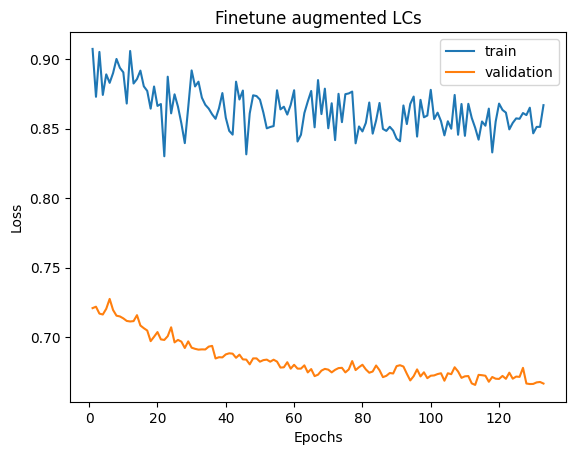

In [28]:
plt.plot(np.arange(len(train_finetune_loss), dtype = int) + 1, train_finetune_loss, label = "train")
plt.plot(np.arange(len(val_finetune_loss), dtype = int) + 1, val_finetune_loss, label = "validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Finetune augmented LCs")
plt.legend()
plt.show()

##### Full model finetune

In [41]:
 
set_seeds()

full_finetune_model = CNN_Model()
full_finetune_model.load_state_dict(torch.load("../models/finetune/finetuned_torch_grad_clipping_v05.pt"))
full_finetune_model.requires_grad_(True) # Not necessary but still..

full_finetune_trainer = Multi_Class_Model_Trainer(full_finetune_model)

train_full_finetune_loss, val_full_finetune_loss = full_finetune_trainer.train(train_original_dataset, validation_original_dataset, optimiser = torch.optim.Adam, learning_rate = 1e-6, lr_shedule = "cosine_annealing",
                                                                max_epochs = 150, patience_early_stopping = 20, threshold_early_stopping = 0.0001, incl_weight = True, print_log = True)

Weights:  tensor([ 0.8551,  1.3625, 10.3447], device='mps:0')
Epoch 0: train_loss=0.8659, val_loss=0.6656, val_acc=0.8432, val_f1_score=[0.90690691 0.90410959 0.22619048]
Epoch 1: train_loss=0.8419, val_loss=0.6613, val_acc=0.8498, val_f1_score=[0.91161867 0.90519878 0.24539877]
Epoch 2: train_loss=0.8606, val_loss=0.6554, val_acc=0.8553, val_f1_score=[0.91897233 0.90352221 0.25157233]
Epoch 3: train_loss=0.8347, val_loss=0.6531, val_acc=0.8553, val_f1_score=[0.91988131 0.90352221 0.25      ]
Epoch 4: train_loss=0.8496, val_loss=0.6584, val_acc=0.8498, val_f1_score=[0.91252485 0.90519878 0.24390244]
Epoch 5: train_loss=0.8447, val_loss=0.6645, val_acc=0.8476, val_f1_score=[0.90909091 0.90853659 0.23952096]
Epoch 6: train_loss=0.8485, val_loss=0.6592, val_acc=0.8509, val_f1_score=[0.91451292 0.90519878 0.24390244]
Epoch 7: train_loss=0.8593, val_loss=0.6557, val_acc=0.8531, val_f1_score=[0.91774034 0.90352221 0.24691358]
Epoch 8: train_loss=0.8562, val_loss=0.6544, val_acc=0.8531, val_f

In [ ]:
torch.save(full_finetune_trainer.model.state_dict(), "../models/full_finetune/full_finetuned_torch_grad_clipping_v03.pt")

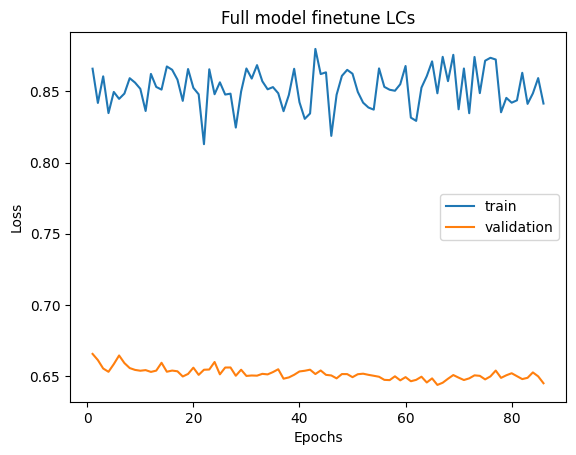

In [42]:
plt.plot(np.arange(len(train_full_finetune_loss), dtype = int) + 1, train_full_finetune_loss, label = "train")
plt.plot(np.arange(len(val_full_finetune_loss), dtype = int) + 1, val_full_finetune_loss, label = "validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Full model finetune LCs")
plt.legend()
plt.show()

#### No MLP intermediate step

In [44]:
 
set_seeds()

no_intermediate_finetuning_model = CNN_Model()
no_intermediate_finetuning_model.load_state_dict(torch.load("../models/pretrain/pretrained_torch_grad_clipping_v02.pt"))
no_intermediate_finetuning_model.requires_grad_(True) # Not necessary but still..

no_intermediate_finetuning_trainer = Multi_Class_Model_Trainer(no_intermediate_finetuning_model)

train_no_intermediate_finetuning_loss, val_no_intermediate_finetuning_loss = no_intermediate_finetuning_trainer.train(train_original_dataset, validation_original_dataset, optimiser = torch.optim.Adam, learning_rate = 1e-6, lr_shedule = "cosine_annealing",
                                                                max_epochs = 150, patience_early_stopping = 20, threshold_early_stopping = 0.0001, incl_weight = True, print_log = True)

Weights:  tensor([ 0.8551,  1.3625, 10.3447], device='mps:0')
Epoch 0: train_loss=0.9063, val_loss=0.7165, val_acc=0.7632, val_f1_score=[0.80879121 0.91285081 0.16033755]
Epoch 1: train_loss=0.8717, val_loss=0.7151, val_acc=0.7675, val_f1_score=[0.81400438 0.91285081 0.16309013]
Epoch 2: train_loss=0.9021, val_loss=0.7095, val_acc=0.7719, val_f1_score=[0.82045702 0.91259259 0.16521739]
Epoch 3: train_loss=0.8721, val_loss=0.7078, val_acc=0.7719, val_f1_score=[0.81917211 0.91420118 0.16521739]
Epoch 4: train_loss=0.8842, val_loss=0.7123, val_acc=0.7697, val_f1_score=[0.81530055 0.91580502 0.1637931 ]
Epoch 5: train_loss=0.8831, val_loss=0.7197, val_acc=0.7654, val_f1_score=[0.81009879 0.91176471 0.16309013]
Epoch 6: train_loss=0.8883, val_loss=0.7118, val_acc=0.7686, val_f1_score=[0.81530055 0.91420118 0.16309013]
Epoch 7: train_loss=0.8989, val_loss=0.7076, val_acc=0.7730, val_f1_score=[0.82045702 0.91420118 0.16593886]
Epoch 8: train_loss=0.8899, val_loss=0.7055, val_acc=0.7774, val_f

In [ ]:
torch.save(no_intermediate_finetuning_trainer.model.state_dict(), "../models/full_finetune/no_intermediate_finetuning_trainer_v01.pt")

##### Original

In [69]:

set_seeds()

original_lcs_path = "../../mallorn_data/combined_multi_class_original_lcs.parq"
original_lcs = Augmented_Dataset(original_lcs_path)

train_original_dataset, validation_original_dataset = torch.utils.data.random_split(original_lcs, [2131, 912])

original_model = CNN_Model()

original_trainer = Multi_Class_Model_Trainer(original_model)

total_train_loss, total_val_loss = original_trainer.train(train_original_dataset, validation_original_dataset, optimiser = torch.optim.Adam, learning_rate = 1e-3, lr_shedule = "cosine_annealing",
                                                                max_epochs = 750, patience_early_stopping = 50, threshold_early_stopping = 0.001, incl_weight = True, print_log = True)

Weights:  tensor([ 0.8551,  1.3625, 10.3447], device='mps:0')
Epoch 0: train_loss=1.1142, val_loss=1.1033, val_acc=0.0504, val_f1_score=[0.00369686 0.         0.09414226]
Epoch 1: train_loss=1.1059, val_loss=1.0983, val_acc=0.0526, val_f1_score=[0.01104972 0.         0.09433962]
Epoch 2: train_loss=1.0992, val_loss=1.0940, val_acc=0.0735, val_f1_score=[0.07829181 0.         0.09625668]
Epoch 3: train_loss=1.0978, val_loss=1.0894, val_acc=0.1064, val_f1_score=[0.17845118 0.         0.09745293]
Epoch 4: train_loss=1.0946, val_loss=1.0848, val_acc=0.0976, val_f1_score=[0.15358362 0.         0.09659715]
Epoch 5: train_loss=1.0795, val_loss=1.0742, val_acc=0.3410, val_f1_score=[0.40234949 0.53775322 0.09333333]
Epoch 6: train_loss=1.0773, val_loss=1.0608, val_acc=0.5614, val_f1_score=[0.76481149 0.3286385  0.11267606]
Epoch 7: train_loss=1.0728, val_loss=1.0603, val_acc=0.4868, val_f1_score=[0.75622776 0.         0.10187668]
Epoch 8: train_loss=1.0639, val_loss=1.0392, val_acc=0.5307, val_f

In [72]:
torch.save(original_trainer.model.state_dict(), "../models/original/original_torch_v01.pt")

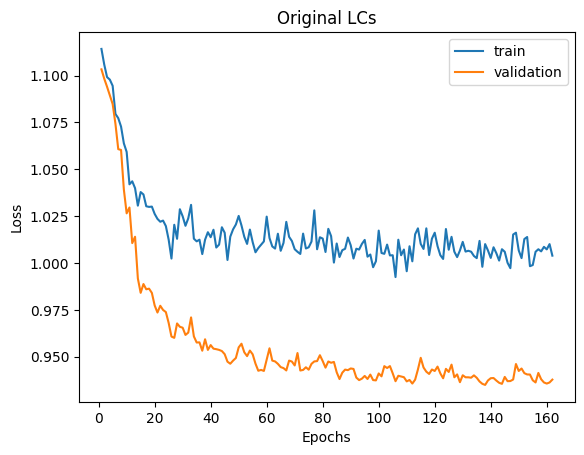

In [70]:
plt.plot(np.arange(len(total_train_loss), dtype = int) + 1, total_train_loss, label = "train")
plt.plot(np.arange(len(total_val_loss), dtype = int) + 1, total_val_loss, label = "validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Original LCs")
plt.legend()
plt.show()

### Test model

In [76]:
# ids
test_lcs_path = "../../mallorn_data/combined_multi_class_original_test_lcs.parq"
test_data = pl.read_parquet(test_lcs_path)

test_ids = test_data["object_id"].to_numpy()


In [87]:
 
test_dataset = Augmented_Dataset(test_lcs_path)

test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = 64, shuffle = False, 
                                              generator = torch.Generator().manual_seed(1337))
test_preds = []

model = CNN_Model()
model.load_state_dict(torch.load("../models/finetune/finetuned_torch_long_earlystopping_v04.pt"))

for lc_data, meta, tgt in test_dataloader:
                    
    pred = model(lc_data.to("mps"), meta.to("mps"))
    test_preds.append(torch.argmax(torch.softmax(pred, dim = 1), dim = 1).cpu())

predictions = torch.cat(test_preds).numpy()
predictions = np.where(predictions == 2, 1, 0)

submission = np.hstack((test_ids, predictions))
submission_df = pd.DataFrame({"object_id": test_ids, "prediction": predictions}, columns=["object_id", "prediction"])
submission_df.to_csv("../submissions/submission_finetuned_torch_long_earlystopping_v04.csv", index = False)

### Simple Random Forest Classifier (Claude)

RF test accuracy: 0.7366666666666667
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       303
           1       0.70      0.78      0.74       293
           2       0.67      0.64      0.65       304

    accuracy                           0.74       900
   macro avg       0.74      0.74      0.74       900
weighted avg       0.74      0.74      0.74       900



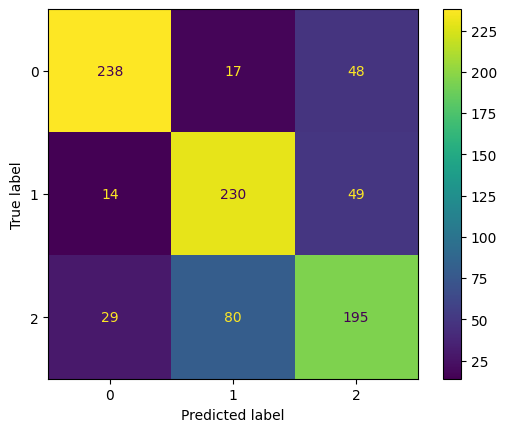

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

augmented_lcs_path = "../../mallorn_data/augmented_lcs/combined_multi_class_augmented_lcs.parq"
augmented_lcs = Augmented_Dataset(augmented_lcs_path)

train_augmented_dataset, test_augmented_dataset = torch.utils.data.random_split(augmented_lcs, [4200, 1800])

# Use simple summary statistics per light curve as features
def extract_features(dataset):
    X, y = [], []
    for i in range(len(dataset)):
        data, _, _, target = dataset[i]
        real = data#[:, ~mask]  # (4, real_len)
        
        time     = real[0].numpy()
        band     = real[1].numpy()
        flux     = real[2].numpy()
        flux_err = real[3].numpy()

        features = []
        # Per band features — most informative for TDE/SNe/AGN discrimination
        for b in range(6):
            m = band == b
            if m.sum() > 2:
                f = flux[m]
                t = time[m]
                features += [
                    f.mean(),                           # mean flux
                    f.std(),                            # variability
                    f.max() - f.min(),                  # amplitude
                    t[f.argmax()] / (time.max() + 1e-8), # time of peak (normalised)
                    np.polyfit(t, f, 1)[0],             # slope (rising/falling)
                    (flux_err[m] / (f + 1e-8)).mean(),  # mean SNR
                ]
            else:
                features += [0] * 6  # band not observed

        # Global features
        features += [
            len(time),                                  # total number of observations
            time.max() - time.min(),                    # duration of observation
            (band == 0).sum() / (len(band) + 1e-8),    # fraction of u band obs
            (band == 1).sum() / (len(band) + 1e-8),    # fraction of g band obs
            (band == 2).sum() / (len(band) + 1e-8),    # fraction of r band obs
        ]

        X.append(features)
        y.append(target.item())

    return np.array(X), np.array(y)

X_train, y_train = extract_features(train_augmented_dataset)
X_test,  y_test   = extract_features(test_augmented_dataset)

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
print("RF test accuracy:", accuracy_score(y_test, rf.predict(X_test)))
print(classification_report(y_test, rf.predict(X_test)))
ConfusionMatrixDisplay.from_predictions(y_test, rf.predict(X_test))


### Visualise data (Claude)

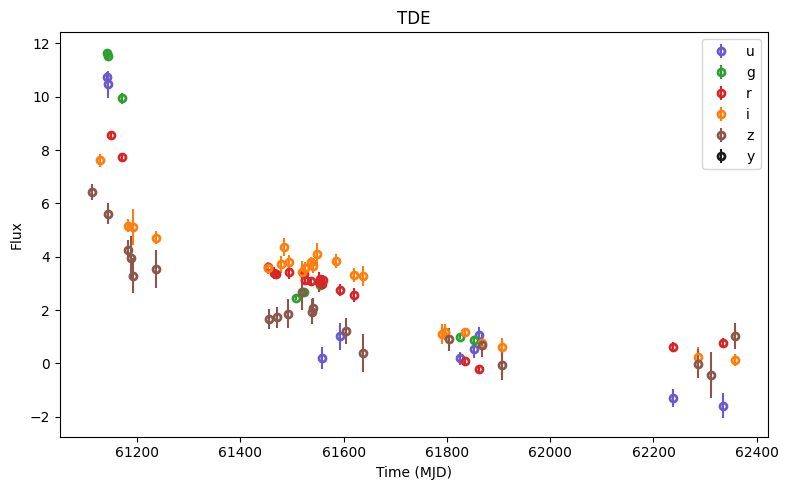

In [ ]:
filter_colours = {'u': '#6A5ACD', 'g': '#2ca02c', 'r': '#d62728', 'i': '#ff7f0e', 'z': '#8c564b', 'y': '#1b1b1b'}

augmented_lcs = Augmented_Dataset(augmented_lcs_path)
train_dataset, test_dataset = torch.utils.data.random_split(augmented_lcs, [5100, 900])

# Pick a random index from train_dataset
id_ = np.random.randint(len(train_dataset))
# train_dataset is a Subset, so we need the underlying index
augmented_idx = train_dataset.indices[id_]

plt.figure(figsize=(8, 5))
for b_ in ['u', 'g', 'r', 'i', 'z', 'y']:
    m_ = augmented_lcs.lcs_parquet[augmented_idx]['BAND'].item() == b_
    plt.errorbar(
        augmented_lcs.lcs_parquet[augmented_idx]['TIME'].item().filter(m_),
        augmented_lcs.lcs_parquet[augmented_idx]['FLUX'].item().filter(m_),
        yerr=augmented_lcs.lcs_parquet[augmented_idx]['FLUXERR'].item().filter(m_),
        ms=5, mew=2, marker='o', color='none',
        ecolor=filter_colours[b_], mec=filter_colours[b_], label=b_
    )

obj_type = augmented_lcs.lcs_parquet[augmented_idx]['type'].item()
plt.title(f"{obj_type}")
plt.xlabel('Time (MJD)')
plt.ylabel('Flux')
plt.legend()
plt.tight_layout()
plt.show()

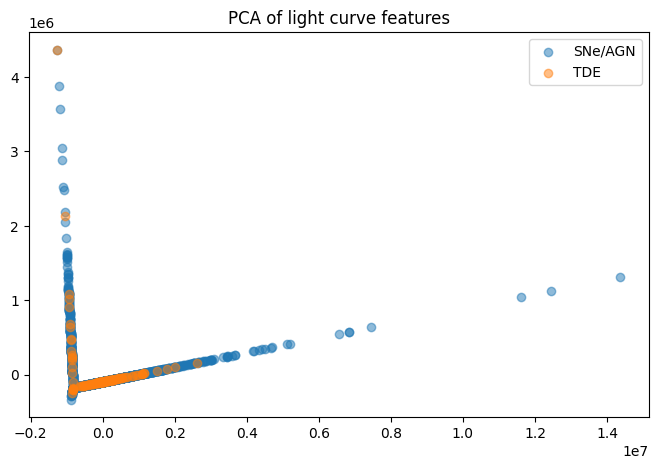

In [69]:
# Check if classes are actually separable
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_train, y_train = extract_features(train_dataset)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[y_train==0, 0], X_pca[y_train==0, 1], alpha=0.5, label='SNe/AGN')
plt.scatter(X_pca[y_train==1, 0], X_pca[y_train==1, 1], alpha=0.5, label='TDE')
plt.legend()
plt.title('PCA of light curve features')
plt.show()